# How to compare multiple AeroMAPS scenarios ?

Prospective scenarios for aviation can be simulated using a wealth of different assumptions and input parameters, also some scenarios may use different models in their estimation, meaning not all scenarios have the same set of outputs. There is the need, therefore, of comparison utilities to harmonize and filter when comparing multiple scenarios at once.

## Creating processes

First, the user has to load the framework and create the multiple process instances to compare.

In [1]:
%matplotlib widget
from aeromaps import create_process

Here, we'll explore 2 different model configurations each with 3 different inputs.

In [2]:
configuration_files = {
    "Advanced": "data/config_advanced.yaml",
    "Basic": "data/config_basic.yaml",
}
traffic_growth_inputs = {
    "Low": 1.0, "Medium": 3.0, "High": 5.0
}

processes_list = []
processes_dict = {}
for config_name, config_file in configuration_files.items():
    for i_name, i_value in traffic_growth_inputs.items():
        process = create_process(configuration_file=config_file)
        process.parameters.cagr_passenger_short_range_reference_periods_values = [i_value]
        process.parameters.cagr_passenger_medium_range_reference_periods_values = [i_value]
        process.parameters.cagr_passenger_long_range_reference_periods_values = [i_value]
        process.parameters.cagr_freight_reference_periods_values = [i_value]

        processes_list.append(process)
        processes_dict[config_name + " - " + i_name] = process

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(


## Assembling processes and computing all

Once processes are created, we'll gather them all in a single AeroMAPSProcessesAssembly object and then compute all internal scenarios.

In [3]:
from aeromaps import assemble_processes

assembly_list = assemble_processes(processes_list)
assembly_dict = assemble_processes(processes_dict)

In practice, the only difference between assembling with lists or with dictionary is how to navigate in them. Therefore we'll only compute one of them.

In [4]:
print(assembly_list[0].parameters.cagr_passenger_short_range_reference_periods_values)
print(assembly_dict["Advanced - Low"].parameters.cagr_passenger_short_range_reference_periods_values)

assembly_dict.compute_all()

[1.0]
[1.0]


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\production_capacity.py:189: UserWarning: 
⚠️ Excess hefa_fog production in years: [2044, 2045]. Scaling down.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\production_capacity.py:189: UserWarning: 
⚠️ Excess hefa_others production in years: [2044, 2045]. Scaling down.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\production_capacity.py:189: UserWarning: 
⚠️ Excess ft_msw production in years: [2044, 2045]. Scaling down.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\production_capacity.py:189: UserWarning: 
⚠️ Excess ft_others production in years: [2044, 2045]. Scaling down.
  warnings.warn(
C:\Users\i.costa-alves\Documents\K

## Plotting scenario results

Now let's see which comparison plots are available, and visualize some of them.

In [5]:
assembly_dict.list_available_plots()

['co2_emissions_comparison',
 'cumulative_co2_emissions_comparison',
 'energy_consumption_comparison',
 'energy_mix_comparison',
 'rpk_comparison',
 'load_factor_comparison',
 'co2_per_rpk_comparison',
 'co2_per_rtk_comparison',
 'energy_per_ask_comparison',
 'energy_per_rtk_comparison',
 'drop_in_supply_breakdown',
 'hydrogen_supply_comparison',
 'electric_supply_comparison',
 'biofuel_production_comparison',
 'electrofuel_production_comparison',
 'biofuel_mix_comparison',
 'total_erf_comparison',
 'temperature_increase_comparison',
 'co2_erf_comparison',
 'non_co2_erf_comparison',
 'energy_expenses_comparison',
 'net_energy_expenses_comparison',
 'doc_comparison',
 'doc_energy_comparison',
 'airfare_comparison',
 'all_energy_costs_per_rpk_comparison']

Here, before plotting a filtering is applied to verify which processes have the output stored. For instance, both configurations estimate CO2 emissions, but only the "Advanced" estimates Temperature increase (as the "Basic" has no climate model configured).

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\plots\multi_scenario_plot.py:521: UserWarning: Scenario 'Basic - Low' is missing required outputs: ['temperature_increase_from_aviation']. It will be excluded from the plot.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\plots\multi_scenario_plot.py:521: UserWarning: Scenario 'Basic - Medium' is missing required outputs: ['temperature_increase_from_aviation']. It will be excluded from the plot.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\plots\multi_scenario_plot.py:521: UserWarning: Scenario 'Basic - High' is missing required outputs: ['temperature_increase_from_aviation']. It will be excluded from the plot.
  warnings.warn(


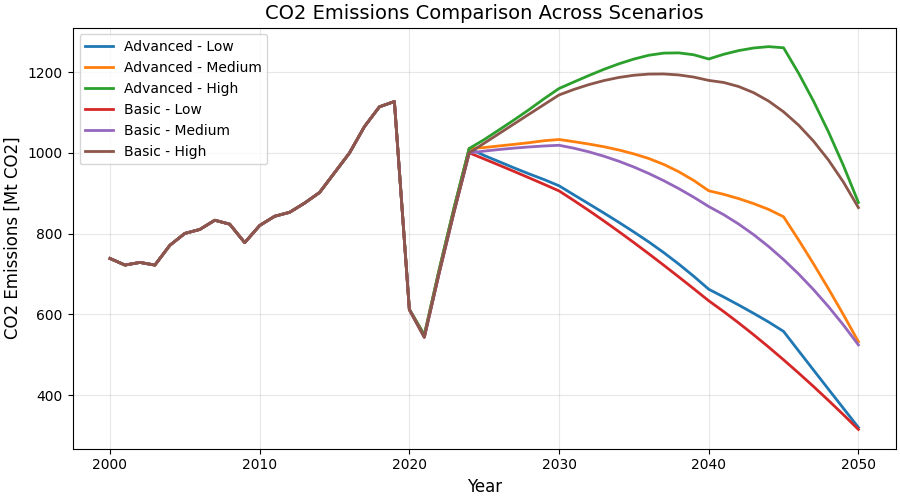

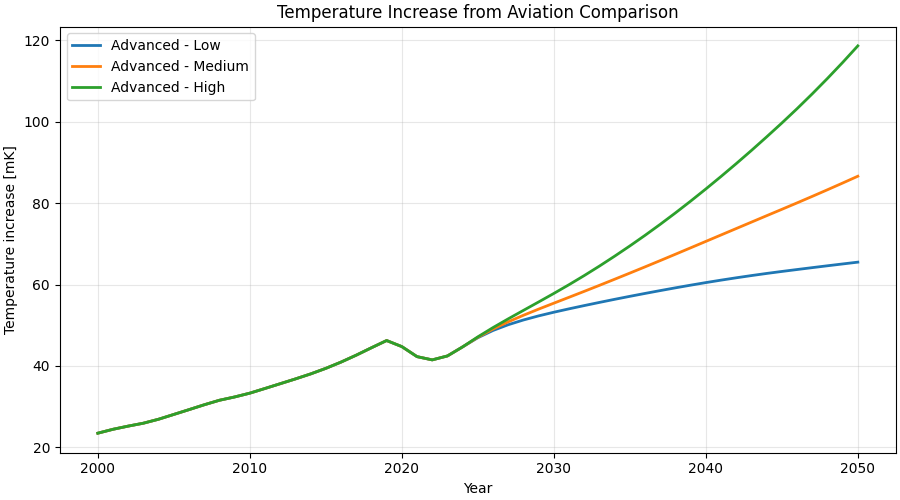

In [6]:
assembly_dict.plot("co2_emissions_comparison")
assembly_dict.plot("temperature_increase_comparison")

Scenarios can also belong to subgroups, which will be shown using the same color, but a different linestyle.

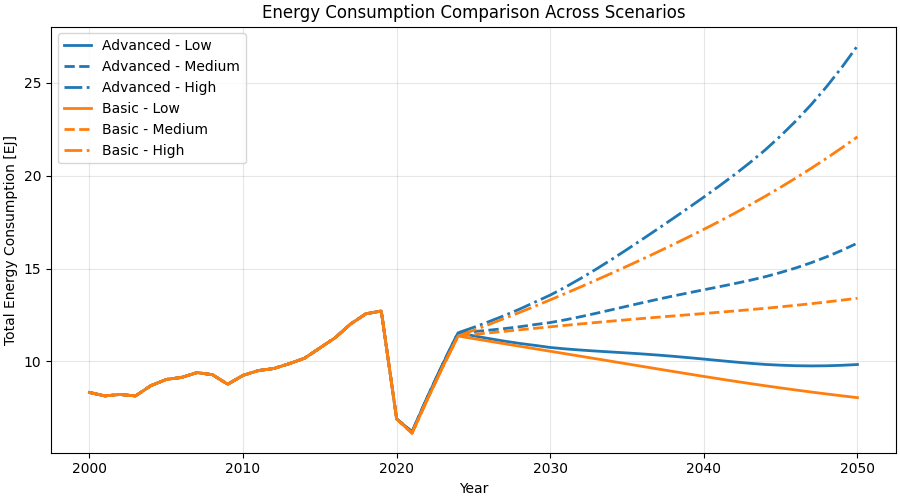

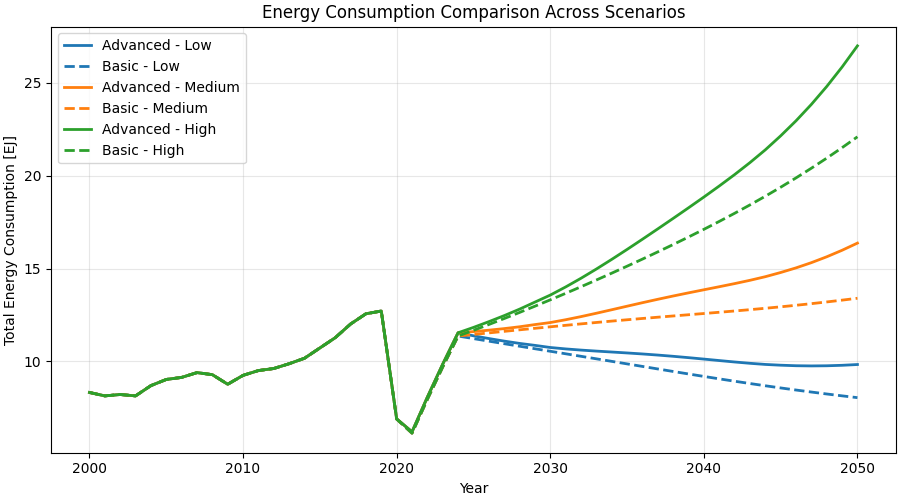

In [7]:
config_groups = {
    config_name: [name for name in processes_dict.keys() if config_name in name]
    for config_name in configuration_files.keys()
}
assembly_dict.plot("energy_consumption_comparison", scenario_groups=config_groups)

traffic_groups = {
    traffic_name: [name for name in processes_dict.keys() if traffic_name in name]
    for traffic_name in traffic_growth_inputs.keys()
}
assembly_dict.plot("energy_consumption_comparison", scenario_groups=traffic_groups)

Subgroups can also be plotted as envelope distributions instead of just line plots

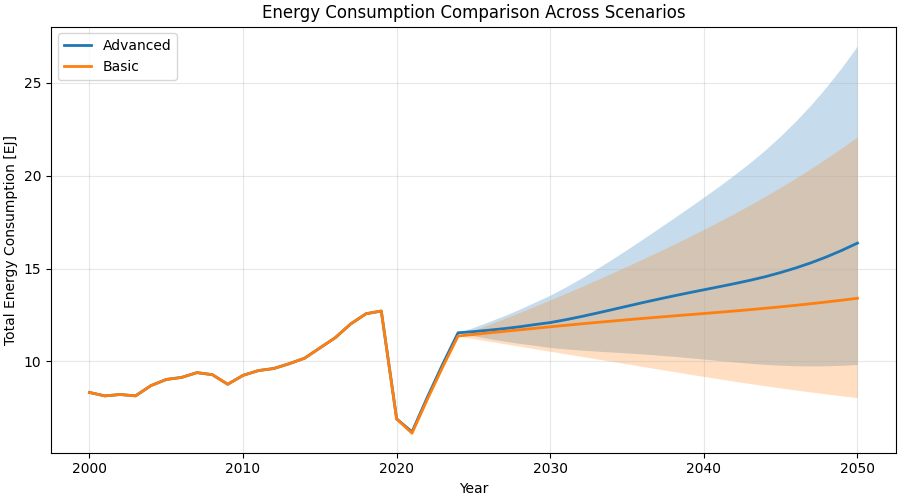

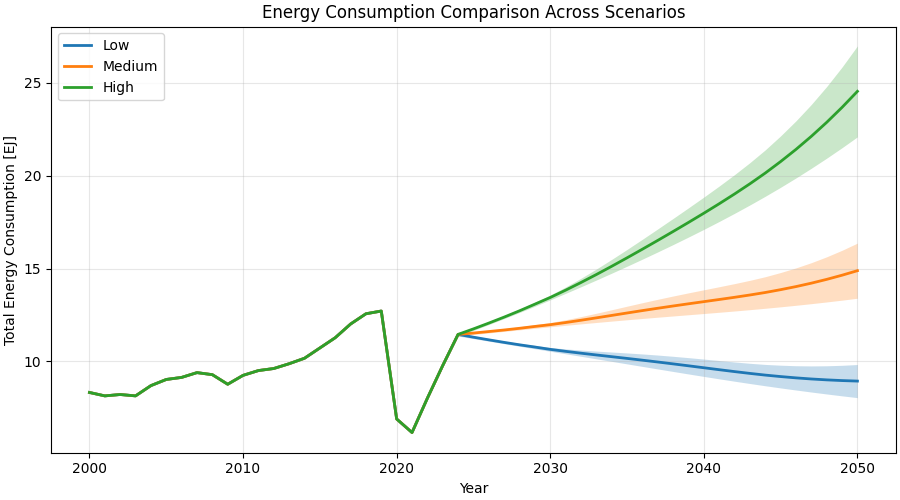

In [8]:
config_groups = {
    config_name: [name for name in processes_dict.keys() if config_name in name]
    for config_name in configuration_files.keys()
}
assembly_dict.plot("energy_consumption_comparison", scenario_groups=config_groups, group_display="envelope")

traffic_groups = {
    traffic_name: [name for name in processes_dict.keys() if traffic_name in name]
    for traffic_name in traffic_growth_inputs.keys()
}
assembly_dict.plot("energy_consumption_comparison", scenario_groups=traffic_groups, group_display="envelope")

In [9]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())